In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color, util
from skimage.exposure import equalize_hist, histogram
from scipy.interpolate import interp1d

##### a) Baixe a imagem colorida do riacho escuro na Figura 6.35 na pasta de imagens do nosso curso. Converta a imagem para RGB. Equalize o histograma das imagens R, G e B separadamente usando o programa de equalização de histograma realizado em tarefa anterior e converta a imagem de volta para o formato TIF.

In [22]:
def equalizer(io_image):
    equalized_img = equalize_hist(io_image)
    return equalized_img

3

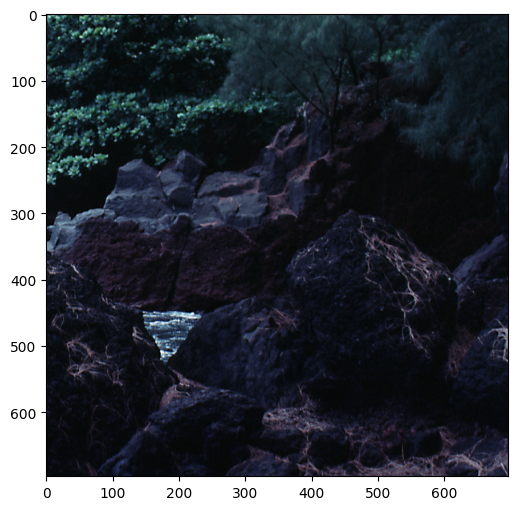

In [23]:
dark_creek = io.imread('./images/FIG063_3.TIF')

plt.figure(figsize=(6, 6))
plt.imshow(dark_creek)
# plt.show()
dark_creek.shape[-1]

In [24]:
# Testa se a imagem está em escala de cinza ou RGBA e converte para RGB se necessário

if dark_creek.ndim == 2:
    print("Imagem em escala de cinza detectada. Convertendo para RGB.")
    
    dark_creek_rgb = color.gray2rgb(dark_creek)
elif dark_creek.shape[2] == 4:
    print("Imagem RGBA detectada. Convertendo para RGB (descartando alfa).")
    dark_creek_rgb = color.rgba2rgb(dark_creek)
    
elif dark_creek.shape[2] == 3:
    print("Imagem já está no formato RGB.")
    dark_creek_rgb = dark_creek
else:
    print(f"Formato de imagem não suportado: {dark_creek.shape}")
    exit(1)

Imagem já está no formato RGB.


Separando canais R, G, B.
Equalizando canal R.
Equalizando canal G.
Equalizando canal B.
Recombinando canais equalizados.


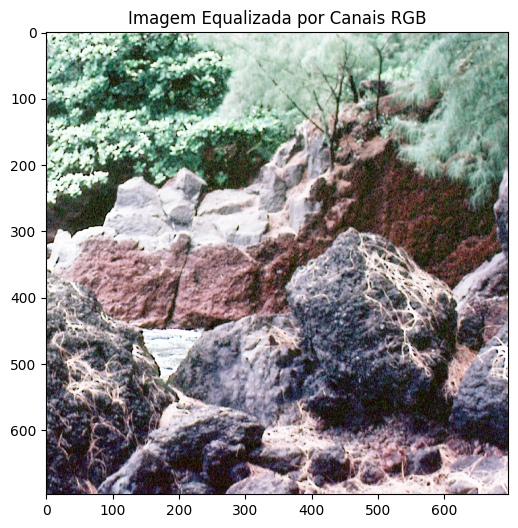

In [25]:

print("Separando canais R, G, B.")
r_channel = dark_creek_rgb[:, :, 0]
g_channel = dark_creek_rgb[:, :, 1]
b_channel = dark_creek_rgb[:, :, 2]

print("Equalizando canal R.")
r_channel_eq = equalizer(r_channel)

print("Equalizando canal G.")
g_channel_eq = equalizer(g_channel)

print("Equalizando canal B.")
b_channel_eq = equalizer(b_channel)

print("Recombinando canais equalizados.")
imagem_eq_rgb = np.dstack((r_channel_eq, g_channel_eq, b_channel_eq))

plt.figure(figsize=(6, 6))
plt.title("Imagem Equalizada por Canais RGB")
plt.imshow(imagem_eq_rgb)


Convertendo imagem final para uint8 (0-255)...

Imagem equalizada salva em: ./outputs/EP2_T1A_independent_RGB_equalized.TIF


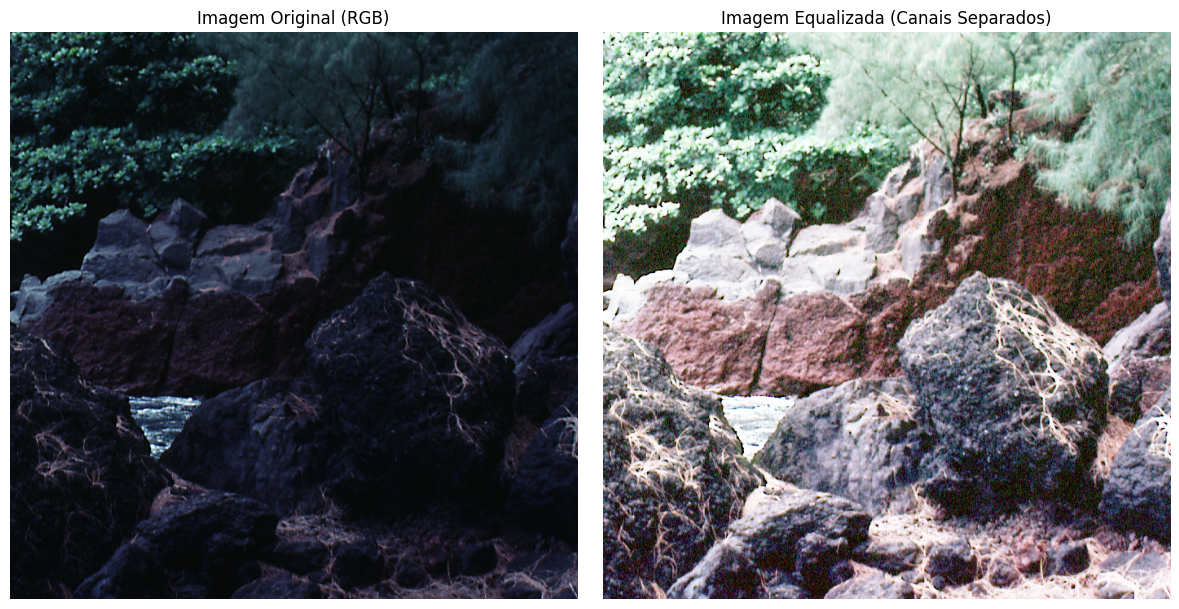

In [26]:
print(f"Convertendo imagem final para uint8 (0-255)...")
dark_creek_final = util.img_as_ubyte(imagem_eq_rgb)

caminho_saida = './outputs/EP2_T1A_independent_RGB_equalized.TIF'

io.imsave(caminho_saida, dark_creek_final)
print(f"\nImagem equalizada salva em: {caminho_saida}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(dark_creek_rgb)
ax[0].set_title("Imagem Original (RGB)")
ax[0].axis('off')

ax[1].imshow(imagem_eq_rgb)
ax[1].set_title("Imagem Equalizada (Canais Separados)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

##### b) Forme um histograma médio a partir dos três histogramas em (a) e use-o como base para obter uma única função de transformação de intensidade de equalização de histograma. Aplique esta função aos componentes R, G e B individualmente e converta os resultados para JPG. Compare e explique as diferenças nas imagens TIF em (a) e (b).

In [27]:
# Calcular histogramas
hist_r, bin_centers_r = histogram(r_channel, nbins=256)
hist_g, _ = histogram(g_channel, nbins=256)
hist_b, _ = histogram(b_channel, nbins=256)

histograma_medio = (hist_r + hist_g + hist_b) / 3.0


In [28]:

# Derivar a função de transformação de intensidade (CDF) a partir do histograma médio
cdf = histograma_medio.cumsum()
cdf_normalizado = cdf * (1. / cdf[-1]) # Normaliza para [0, 1], compatível com o retorno de equalize_hist

# Criar a função de mapeamento (interpolação em 1 dimensão)
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html
funcao_transformacao_media = interp1d(
bin_centers_r, cdf_normalizado, kind='linear', bounds_error=False, fill_value="extrapolate"
)
print("Função de transformação derivada do histograma médio.")

# Aplicar esta função de transformação única aos componentes R, G e B
r_channel_eq_media = funcao_transformacao_media(r_channel)
g_channel_eq_media = funcao_transformacao_media(g_channel)
b_channel_eq_media = funcao_transformacao_media(b_channel)

# Recombinar os canais
# Garantir que os valores permaneçam no intervalo [0, 1] após a interpolação
imagem_eq_rgb_media = np.dstack((
np.clip(r_channel_eq_media, 0.0, 1.0),
np.clip(g_channel_eq_media, 0.0, 1.0),
np.clip(b_channel_eq_media, 0.0, 1.0)
))


Função de transformação derivada do histograma médio.


Imagem equalizada (média) salva em: ./outputs/EP2_T1B_mean_histogram_equalized.TIF


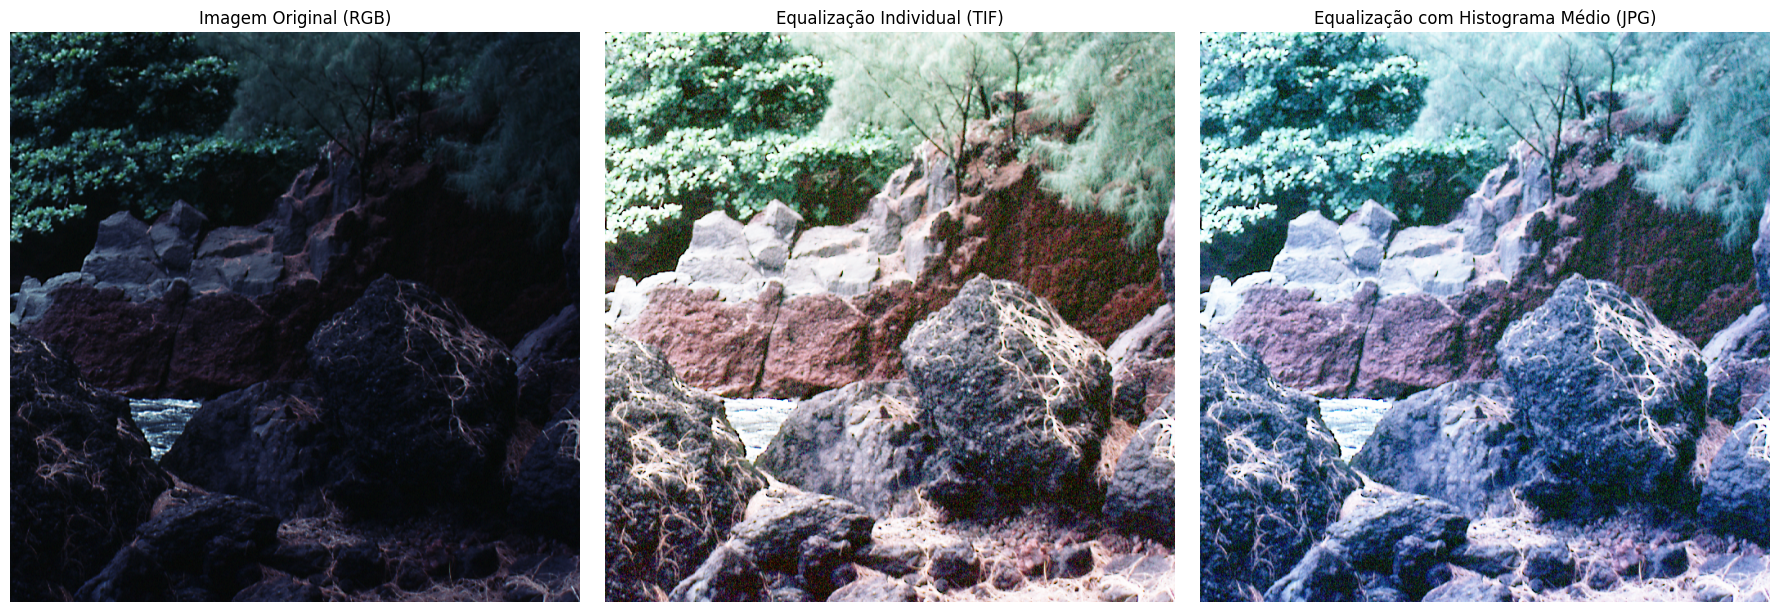

In [29]:
caminho_saida_jpg_media = './outputs/EP2_T1B_mean_histogram_equalized.TIF'
io.imsave(caminho_saida_jpg_media, util.img_as_ubyte(imagem_eq_rgb_media))
print(f"Imagem equalizada (média) salva em: {caminho_saida_jpg_media}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(dark_creek)
ax[0].set_title("Imagem Original (RGB)")
ax[0].axis('off')

ax[1].imshow(dark_creek_final)
ax[1].set_title("Equalização Individual (TIF)")
ax[1].axis('off')

ax[2].imshow(imagem_eq_rgb_media)
ax[2].set_title("Equalização com Histograma Médio (JPG)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

##### c) A partir do resultado obtido utilize da técnica desta tarefa com uma ou mais imagens da sua base de dados. A partir de uma análise comparativa, conclua sobre os resultados obtidos.

Iniciando Tarefa 1 (Equalização Individual)...
Saída TIF (individual) salva em: ./outputs/EP2_T1C_saida_individual.tif
Iniciando Equalização por Histograma Médio.
Saída JPG (média) salva em: ./outputs/EP2_T1C_saida_media.jpg
Exibindo comparações.


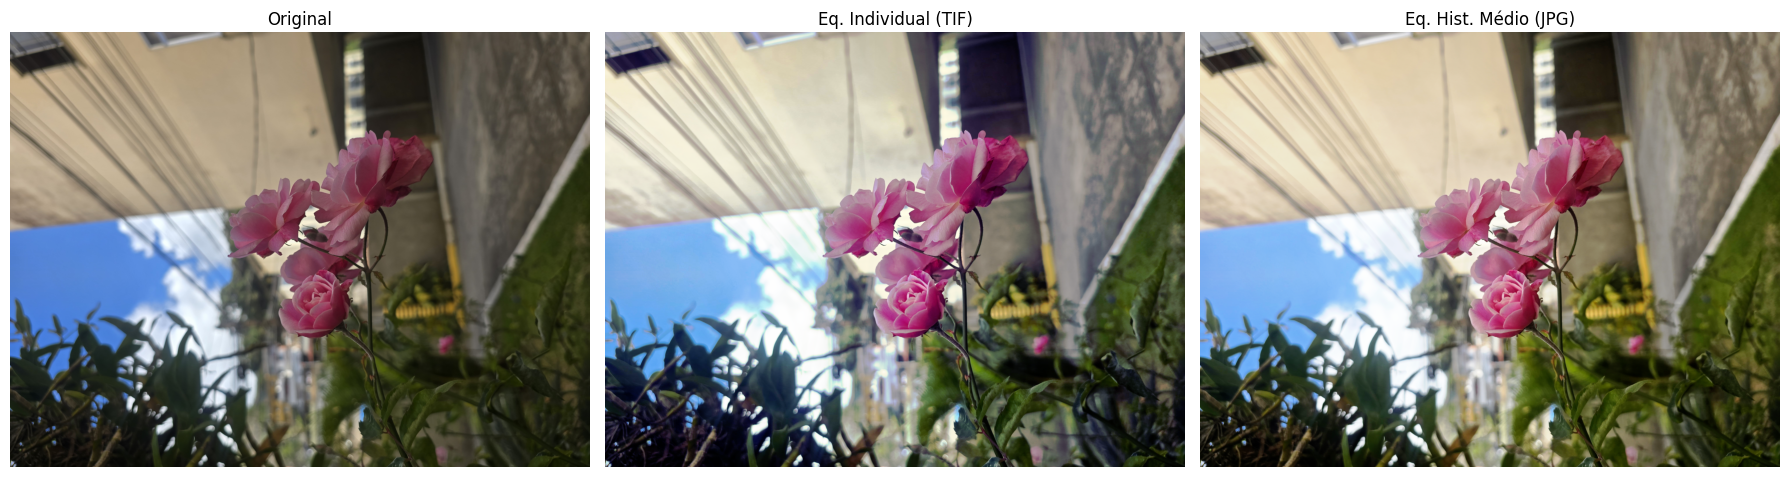

In [30]:
imagem = io.imread('./images/flor_o_d_01.jpg')

if imagem.ndim == 2:
    imagem_rgb_float = util.img_as_float(color.gray2rgb(imagem))
elif imagem.shape[2] == 4:
    imagem_rgb_float = util.img_as_float(color.rgba2rgb(imagem))
else:
    imagem_rgb_float = util.img_as_float(imagem)

r_canal = imagem_rgb_float[:, :, 0]
g_canal = imagem_rgb_float[:, :, 1]
b_canal = imagem_rgb_float[:, :, 2]

# Equalização Individual (TIF)
print("Iniciando Tarefa 1 (Equalização Individual)...")
r_canal_eq_ind = equalize_hist(r_canal)
g_canal_eq_ind = equalize_hist(g_canal)
b_canal_eq_ind = equalize_hist(b_canal)

imagem_eq_rgb_individual = np.dstack((r_canal_eq_ind, g_canal_eq_ind, b_canal_eq_ind))

caminho_saida_tif_individual = './outputs/EP2_T1C_saida_individual.tif'
io.imsave(caminho_saida_tif_individual, util.img_as_ubyte(imagem_eq_rgb_individual))
print(f"Saída TIF (individual) salva em: {caminho_saida_tif_individual}")

# Equalização por Histograma Médio (JPG)
print("Iniciando Equalização por Histograma Médio.")

hist_r, bin_centers = histogram(r_canal, nbins=256)
hist_g, _ = histogram(g_canal, nbins=256)
hist_b, _ = histogram(b_canal, nbins=256)

histograma_medio = (hist_r + hist_g + hist_b) / 3.0

cdf = histograma_medio.cumsum()
cdf_normalizado = cdf * (1. / cdf[-1])

funcao_transformacao_media = interp1d(
    bin_centers, cdf_normalizado, kind='linear', bounds_error=False, fill_value="extrapolate"
)

r_canal_eq_media = funcao_transformacao_media(r_canal)
g_canal_eq_media = funcao_transformacao_media(g_canal)
b_canal_eq_media = funcao_transformacao_media(b_canal)

imagem_eq_rgb_media = np.dstack((
    np.clip(r_canal_eq_media, 0.0, 1.0),
    np.clip(g_canal_eq_media, 0.0, 1.0),
    np.clip(b_canal_eq_media, 0.0, 1.0)
))

caminho_saida_jpg_media = './outputs/EP2_T1C_saida_media.jpg'
io.imsave(caminho_saida_jpg_media, util.img_as_ubyte(imagem_eq_rgb_media))
print(f"Saída JPG (média) salva em: {caminho_saida_jpg_media}")

# --- Visualização de Comparação ---
print("Exibindo comparações.")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(imagem_rgb_float)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(imagem_eq_rgb_individual)
ax[1].set_title("Eq. Individual (TIF)")
ax[1].axis('off')

ax[2].imshow(imagem_eq_rgb_media)
ax[2].set_title("Eq. Hist. Médio (JPG)")
ax[2].axis('off')

plt.tight_layout()
plt.show()